# Long-Shot 🎯
### Do 'lottery' commodities underperform? The skewness effect, leaning the right way

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Skewness effect is real?: Supported](https://img.shields.io/badge/Skewness_effect_is_real%3F-Supported-8b949e?style=flat-square)

People overpay for long-shots — assets with a small chance of a big payoff (positive skewness). So positively-skewed commodities should be over-bid and underperform the boring low-skew ones. On a basket of commodity ETFs the trade points the right way (~+5%/yr) and stays stable — but the universe is too small to prove it.

> 📓 **Plain-language layer.** The t-stat, persistence and costs are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (long_shot/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from long_shot import data, strategy as st
daily = data.fetch_panel()                     # cache-first
sig = st.skewness_signal(daily)
h = st.cross_section_hedge(daily, sig, long_high=False)   # long low-skew


## The answer first 🎯

| The claim | The data (2009–2026) |
|---|---|
| "Low-skew commodities out-earn" | True direction: **+5.2%/yr**, hit **53%**. |
| "A strong effect" | Modest: **Sharpe 0.27 (t 1.1)** on 14 ETFs. |
| "Tradable" | Costs thin it: net **0.19 at 10 bp**. |

## 1 · The claim

Fuertes-Miffre-Fernandez (2015): rank commodities by the skewness of their recent returns; the positively-skewed (lottery-like) ones underperform because they're over-bid. Long low-skew, short high-skew — the commodity cousin of the equity lottery effect.

## 2 · So what?

If the lottery bias prices commodities too, it's a behavioural premium you can harvest with a simple skewness sort. And unlike the equity version (which inverted on large caps), the commodity version might survive — worth a careful look.

## 3 · How would we even know?

Measure each commodity's trailing-year skewness, sort, go long the low-skew third and short the high-skew, and check the sign, significance, persistence and cost-sensitivity.

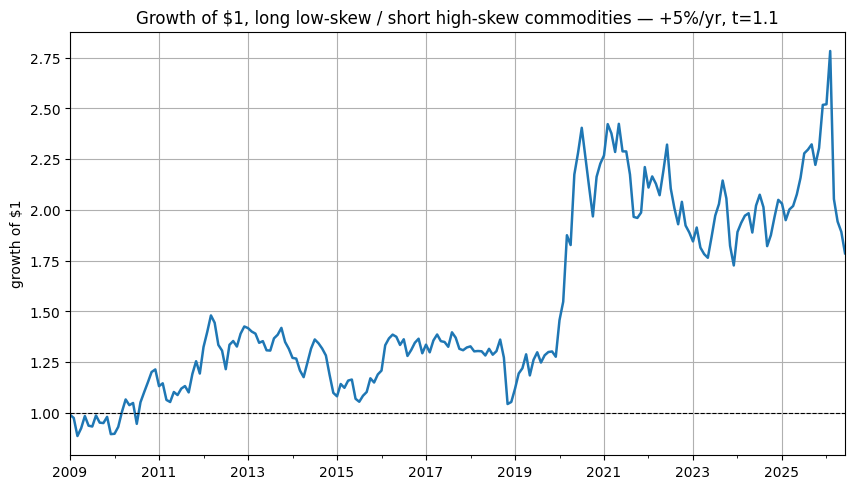

In [2]:
s=st.stats(h); eq=(1+h).cumprod()
ax=eq.plot(title=f"Growth of $1, long low-skew / short high-skew commodities — {s['mean_ann']:+.0%}/yr, t={s['tstat']:.1f}",lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

## 4 · The teardown

A steady climb the right way — and stable across the sample, unlike the inverted equity lottery studies. But the line is gentle and the basket small.

In [3]:
for lab,sl in [('2009-2017',h.loc[:'2017']),('2018-on',h.loc['2018':])]:
    print(f'{lab}: Sharpe {st.stats(sl)["sharpe"]:+.2f}')
for c in (0,10,25): print(f'net Sharpe @ {c}bp: {st.stats(st.net_of_cost(h,c))["sharpe"]:+.2f}')

2009-2017: Sharpe +0.28
2018-on: Sharpe +0.27
net Sharpe @ 0bp: +0.27
net Sharpe @ 10bp: +0.19
net Sharpe @ 25bp: +0.08


**Read it plainly.** Low-skew commodities really did beat high-skew, persistently — the lottery story holds in commodities. The catch is breadth (14 ETFs) and cost, not direction.

## 5 · The verdict

**Signal: Weak** — right sign, stable, but t 1.1. **Tradability: Fragile** — costs thin it. **Skewness effect real?: Supported** by sign + literature.

## 6 · Could you actually trade it?

With a broader futures universe (20–30 markets) and cheap execution, plausibly — it points the right way and doesn't decay. On 14 ETFs with roll drag, the edge is real but thin; you'd want more breadth to bank it.

## 7 · Going further 🚪

The commodity analogue of the *inverted* equity lottery studies [53 Jackpot](../../53-jackpot/) / [54 Static](../../54-static/) — here the lottery story survives. This closes the third ten-study bench (51–60).